# RPA collective modes and Stoner/RPA instability detection

`h.get_rpa_kernel_poles` scans the RPA kernel $1-U\chi(q,\omega)$ at fixed $q$ and returns every
frequency where it becomes singular: these poles are the system's collective modes. If a kernel
eigenvalue instead crosses zero exactly at $\omega=0$, that signals a Stoner/RPA instability of the
normal state itself, rather than a genuine propagating mode. `h.get_magnon_bands` specializes this to
the full spin channel and scans a q-path, directly giving the magnon dispersion of a magnetically
ordered mean-field state (`h.get_plasmon_bands` is the charge-channel analog).

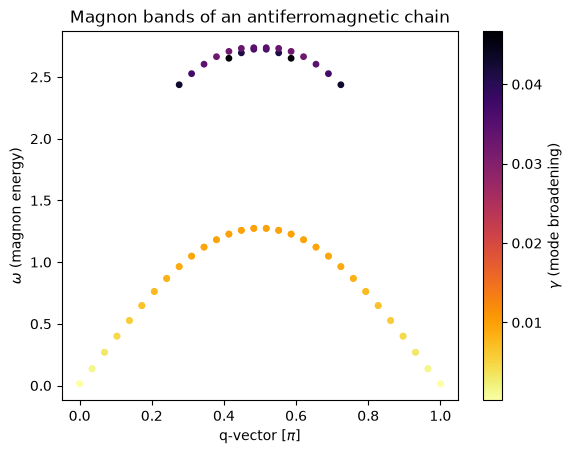

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
g = geometry.bichain()
h = g.get_hamiltonian()
hmf = h.copy() ; hmf.add_antiferromagnetism(0.5) # symmetry-breaking seed
h = h.get_mean_field_hamiltonian(U=3.0,nk=60,mf=hmf,filling=0.5)

nq = 30
energies = np.linspace(0.01,4.,150) # omega=0 excluded: trivial root of every kernel
qs,ws,gammas = h.get_magnon_bands(nq=nq,energies=energies,delta=2e-2,nk=60)

sharp = np.abs(gammas) < 0.05 # keep only well-defined branches
qs,ws,gammas = qs[sharp],ws[sharp],gammas[sharp]

plt.scatter(qs/(nq-1),ws,c=gammas,cmap="inferno_r",s=15)
plt.colorbar(label="$\gamma$ (mode broadening)")
plt.xlabel("q-vector [$\pi$]") ; plt.ylabel("$\omega$ (magnon energy)")
plt.title("Magnon bands of an antiferromagnetic chain")
plt.show()